In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import time
import pickle
import pybobyqa

from IPython.display import display
from pathlib import Path

sys.path.insert(0, str(Path("../JAMDiFF_library").resolve()))
from get_JAM_DiFF import get_JAM_DiFF_dict


Settings


In [2]:
c = 1 

fit_name = "Default"
if_generate_grids = False
N_cores = 16
N_replicas = 900
replica_seed = 12345

grid_file = Path("../Grids/dict_raw_DiFF_ee_EEC_exact.pkl")
fit_results_dir = Path("EE_EEC_fit_results")
fit_results_dir.mkdir(exist_ok=True)

z_array = np.linspace(0.19, 0.99, 20)
Mh_array = np.linspace(0.28, 2.05, 50)
kinds = ["D1"]
wdir = "results/wLQCD"

data_dir = Path("../Data")
excluded_datasets = {"OPAL_old", "TASSO_140", "DELPHI", "SLD"}

min_points_shape = 2
fit_bounds = (-5.0, 5.0)
optimizer_maxfun = 500
optimizer_rhobeg = 0.15
optimizer_rhoend = 1e-5


Setup


In [3]:
Main.eval("using Distributed")
current_nworkers = int(Main.eval("nworkers()"))
if N_cores > current_nworkers:
    Main.eval(f"addprocs({N_cores - current_nworkers})")

fitting_root = "../"
def include(name):
    path = os.path.join(fitting_root, name)
    Main.eval(f'@everywhere include(raw"{path}")')

card_name = fit_name.removesuffix(".jl")
include(f"Cards/{card_name}.jl")
include("Collinear_PDF/pdf.jl")
include("Core/constants.jl")
include("Core/strong coupling.jl")
include("Numerical/FastGK.jl")
include("DiFF_EEC/DiFF_EEC.jl")
include("Processes/ee/ee_EEC.jl")


      From worker 13:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 13:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 12:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 12:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 12:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transversity_lo/JAMDiFF23-transversity_lo_0000.dat
      From worker 12:	JAMDiFF23-transversity_lo PDF set, member #0, version 1; LHAPDF ID = 1
      From worker 16:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 16:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 16:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transversity_lo/JAMDiFF2

Load Data


In [4]:
def load_ee_eec_datasets(data_dir, *, min_points_shape=2, excluded_datasets=None):
    datasets = []
    excluded_datasets = set() if excluded_datasets is None else {str(name) for name in excluded_datasets}

    for path in sorted(data_dir.glob("*.csv")):
        if path.stem in excluded_datasets:
            continue
        df = pd.read_csv(path)
        if not {"CHI", "EEC", "Q"}.issubset(df.columns):
            continue

        chi_deg = pd.to_numeric(df["CHI"], errors="coerce").to_numpy(dtype=float)
        eec = pd.to_numeric(df["EEC"], errors="coerce").to_numpy(dtype=float)
        Q = pd.to_numeric(df["Q"], errors="coerce").to_numpy(dtype=float)

        if "ERROR" in df.columns:
            error = pd.to_numeric(df["ERROR"], errors="coerce").to_numpy(dtype=float)
        else:
            stat = pd.to_numeric(df.get("STAT", np.nan), errors="coerce").to_numpy(dtype=float)
            syst = pd.to_numeric(df.get("SYS", 0.0), errors="coerce").to_numpy(dtype=float)
            error = np.sqrt(stat**2 + syst**2)

        chi = np.deg2rad(chi_deg)
        zchi = (1 - np.cos(chi)) / 2
        keep = (
            np.isfinite(chi_deg)
            & np.isfinite(eec)
            & np.isfinite(Q)
            & np.isfinite(error)
            & (error > 0)
            & (np.sqrt(zchi) * Q <= 7.0)
        )
        if not np.any(keep):
            continue

        chi_deg = chi_deg[keep]
        chi = chi[keep]
        eec = eec[keep]
        error = error[keep]
        Q = Q[keep]

        order = np.argsort(chi_deg)
        chi_deg = chi_deg[order]
        chi = chi[order]
        eec = eec[order]
        error = error[order]
        Q = Q[order]

        q_values = sorted({float(v) for v in Q})
        if len(q_values) != 1:
            raise ValueError(f"Expected a single Q value in {path.name}, found {q_values}")

        datasets.append(
            {
                "name": path.stem,
                "file": path.name,
                "Q": float(q_values[0]),
                "mu": float(c * q_values[0]),
                "chi_deg": chi_deg,
                "chi": chi,
                "EEC": eec,
                "ERROR": error,
                "npts": int(len(chi_deg)),
                "used_in_shape_fit": bool(len(chi_deg) >= int(min_points_shape)),
            }
        )

    datasets.sort(key=lambda item: (item["Q"], item["name"]))
    return datasets


datasets = load_ee_eec_datasets(
    data_dir,
    min_points_shape=min_points_shape,
    excluded_datasets=excluded_datasets,
)
fit_datasets = [dataset for dataset in datasets if dataset["used_in_shape_fit"]]

if not datasets:
    raise ValueError(f"No usable datasets found in {data_dir}")
if not fit_datasets:
    raise ValueError("No datasets have enough points for a shape-only fit")

data_mu_values = np.array(sorted({dataset["mu"] for dataset in datasets}), dtype=float)
summary_df = pd.DataFrame(
    {
        "dataset": [dataset["name"] for dataset in datasets],
        "Q": [dataset["Q"] for dataset in datasets],
        "mu": [dataset["mu"] for dataset in datasets],
        "npts_usable": [dataset["npts"] for dataset in datasets],
        "used_in_shape_fit": [dataset["used_in_shape_fit"] for dataset in datasets],
    }
)
display(summary_df)
print(f"Excluded datasets: {sorted(excluded_datasets)}")
print(f"Using {len(fit_datasets)} multi-point datasets for chi2_shape")


,dataset,Q,mu,npts_usable,used_in_shape_fit
0,TASSO_220,22.0,22.0,9,True
1,MAC,29.0,29.0,7,True
2,MARK II,29.0,29.0,7,True
3,TASSO_348,34.8,34.8,5,True
4,TASSO_435,43.5,43.5,4,True
5,TOPAZ_533,53.3,53.3,3,True
6,TOPAZ_595,59.5,59.5,3,True
7,OPAL_new,91.2,91.2,8,True


Excluded datasets: ['DELPHI', 'OPAL_old', 'SLD', 'TASSO_140']
Using 8 multi-point datasets for chi2_shape


Load JAM Grid


In [5]:
mu_array = data_mu_values

if if_generate_grids:
    dict_raw_DiFF = get_JAM_DiFF_dict(
        z_array=z_array,
        Mh_array=Mh_array,
        mu_array=mu_array,
        kinds=kinds,
        wdir=wdir,
    )

    with grid_file.open("wb") as f:
        pickle.dump(dict_raw_DiFF, f, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with grid_file.open("rb") as f:
        dict_raw_DiFF = pickle.load(f)

required_mu_keys = {np.float16(mu) for mu in mu_array}
keys = [key for key in dict_raw_DiFF.keys() if isinstance(key, tuple) and key[0] == "D1"]
available_mu_keys = {np.float16(key[1]) for key in keys if int(key[2]) == 0}
missing_mu_values = [float(mu) for mu in mu_array if np.float16(mu) not in available_mu_keys]
if missing_mu_values:
    raise KeyError(f"Missing exact D1 grid entries for mu = {missing_mu_values} in {grid_file}")

Main.dict_raw_DiFF = {key: value for key, value in dict_raw_DiFF.items()}
Main.eval('''let payload = dict_raw_DiFF
    @everywhere global dict_raw_DiFF = $payload
end''')

selected_keys = [key for key in keys if int(key[2]) == 0 and np.float16(key[1]) in required_mu_keys]
Main.selected_keys = list(selected_keys)
Main.eval('''let payload = selected_keys
    @everywhere global selected_keys = $payload
end''')
include("Grids/initialization.jl")

print(f"Loaded exact D1 grid from {grid_file}")
print(f"mu_array = {mu_array.tolist()}")


Loaded exact D1 grid from ../Grids/dict_raw_DiFF_ee_EEC_exact.pkl
mu_array = [22.0, 29.0, 34.8, 43.5, 53.3, 59.5, 91.2]


Fit Helpers


In [6]:
def set_d1_coeffs(a, b):
    a = float(a)
    b = float(b)
    Main.a_D1 = a
    Main.b_D1 = b
    Main.eval(
        f'''@everywhere begin
            global a_D1 = {a}
            global b_D1 = {b}
        end'''
    )


def build_prediction_inputs(dataset_list):
    chi = np.concatenate([np.asarray(dataset["chi"], dtype=float) for dataset in dataset_list])
    Q = np.concatenate([np.full(dataset["npts"], dataset["Q"], dtype=float) for dataset in dataset_list])
    mu = np.concatenate([np.full(dataset["npts"], dataset["mu"], dtype=float) for dataset in dataset_list])
    slices = []
    start = 0
    for dataset in dataset_list:
        stop = start + dataset["npts"]
        slices.append((dataset, slice(start, stop)))
        start = stop
    return {"chi": chi, "Q": Q, "mu": mu, "rep": np.zeros(len(chi), dtype=int), "slices": slices}


fit_inputs = build_prediction_inputs(fit_datasets)
all_inputs = build_prediction_inputs(datasets)
_prediction_cache = {}
_eval_history = []


def evaluate_batch(inputs):
    nworkers = int(Main.eval("nworkers()"))
    if nworkers > 0:
        values, elapsed = Main.EE_EEC_pmap(
            chi_array=inputs["chi"],
            Q_array=inputs["Q"],
            mu_array=inputs["mu"],
            rep=inputs["rep"],
        )
        return np.asarray(values, dtype=float), float(elapsed)

    t0 = time.perf_counter()
    values = [
        Main.EE_EEC(chi=float(chi), Q=float(Q), mu=float(mu), rep=int(rep))
        for chi, Q, mu, rep in zip(inputs["chi"], inputs["Q"], inputs["mu"], inputs["rep"])
    ]
    return np.asarray(values, dtype=float), float(time.perf_counter() - t0)


def profile_normalization(theory, data, sigma):
    weights = 1.0 / np.square(sigma)
    denom = np.sum(weights * np.square(theory))
    if not np.isfinite(denom) or denom <= 0.0:
        return np.nan, np.inf
    norm = np.sum(weights * data * theory) / denom
    resid = data - norm * theory
    chi2 = np.sum(np.square(resid / sigma))
    return float(norm), float(chi2)


def predict_points(a, b, inputs, *, use_cache=True):
    key = None
    if use_cache:
        key = (round(float(a), 10), round(float(b), 10), len(inputs["chi"]))
        if key in _prediction_cache:
            return _prediction_cache[key]

    set_d1_coeffs(a, b)
    pred, elapsed = evaluate_batch(inputs)
    result = {"pred": pred, "elapsed": elapsed}
    if key is not None:
        _prediction_cache[key] = result
    return result


def chi2_shape_from_prediction(pred_flat, inputs, *, return_details=False):
    total = 0.0
    details = []
    for dataset, dataset_slice in inputs["slices"]:
        theory = pred_flat[dataset_slice]
        norm, chi2 = profile_normalization(theory, dataset["EEC"], dataset["ERROR"])
        total += chi2
        details.append(
            {
                "dataset": dataset["name"],
                "Q": dataset["Q"],
                "npts": dataset["npts"],
                "norm_profile": norm,
                "chi2_shape": chi2,
                "chi2_shape_per_point": chi2 / dataset["npts"],
                "used_in_shape_fit": dataset["used_in_shape_fit"],
            }
        )
    if return_details:
        return float(total), pd.DataFrame(details)
    return float(total)


def evaluate_shape_point(a, b, *, verbose=False):
    result = predict_points(a, b, fit_inputs)
    chi2_shape, detail_df = chi2_shape_from_prediction(result["pred"], fit_inputs, return_details=True)
    if verbose:
        print(f"a_D1={a:+.5f}, b_D1={b:+.5f}, chi2_shape={chi2_shape:.6f}, eval_time={result['elapsed']:.2f}s")
    return {
        "a_D1": float(a),
        "b_D1": float(b),
        "chi2_shape": float(chi2_shape),
        "detail_df": detail_df,
        "pred": result["pred"],
        "elapsed": result["elapsed"],
    }


def objective(params):
    out = evaluate_shape_point(params[0], params[1], verbose=True)
    _eval_history.append(
        {
            "a_D1": out["a_D1"],
            "b_D1": out["b_D1"],
            "chi2_shape": out["chi2_shape"],
            "eval_time": out["elapsed"],
        }
    )
    return out["chi2_shape"]


def build_profiled_comparison(a, b, dataset_list=None):
    if dataset_list is None:
        dataset_list = datasets
    inputs = build_prediction_inputs(dataset_list)
    result = predict_points(a, b, inputs, use_cache=False)

    rows = []
    for dataset, dataset_slice in inputs["slices"]:
        theory = result["pred"][dataset_slice]
        norm, chi2 = profile_normalization(theory, dataset["EEC"], dataset["ERROR"])
        theory_profiled = norm * theory
        for chi_deg, data, sigma, theory_raw, theory_fit in zip(
            dataset["chi_deg"],
            dataset["EEC"],
            dataset["ERROR"],
            theory,
            theory_profiled,
        ):
            rows.append(
                {
                    "dataset": dataset["name"],
                    "Q": dataset["Q"],
                    "chi_deg": float(chi_deg),
                    "data": float(data),
                    "error": float(sigma),
                    "theory_raw": float(theory_raw),
                    "theory_profiled": float(theory_fit),
                    "norm_profile": float(norm),
                    "chi2_shape_dataset": float(chi2),
                    "used_in_shape_fit": bool(dataset["used_in_shape_fit"]),
                }
            )
    return pd.DataFrame(rows)


shape_npts = int(sum(dataset["npts"] for dataset in fit_datasets))
shape_ndatasets = int(len(fit_datasets))
shape_ndof = int(shape_npts - shape_ndatasets - 2)
print(f"Shape-fit dof = {shape_npts} - {shape_ndatasets} profiled norms - 2 parameters = {shape_ndof}")


Shape-fit dof = 46 - 8 profiled norms - 2 parameters = 36


Warm Up


In [7]:
set_d1_coeffs(0.0, 0.0)

warmup_value = Main.EE_EEC(
    chi=float(fit_inputs["chi"][0]),
    Q=float(fit_inputs["Q"][0]),
    mu=float(fit_inputs["mu"][0]),
    rep=0,
)

warmup_values, warmup_time = evaluate_batch(
    {
        "chi": fit_inputs["chi"][:2],
        "Q": fit_inputs["Q"][:2],
        "mu": fit_inputs["mu"][:2],
        "rep": fit_inputs["rep"][:2],
    }
)

display(warmup_value)
display((len(warmup_values), warmup_time))


0.007179707997806098

(2, 2.123280094)

Run Fit


In [8]:
lower = np.array([fit_bounds[0], fit_bounds[0]], dtype=float)
upper = np.array([fit_bounds[1], fit_bounds[1]], dtype=float)
x0 = np.array([0.0, 0.0], dtype=float)

_prediction_cache.clear()
_eval_history.clear()

t0_fit = time.perf_counter()
solution = pybobyqa.solve(
    objective,
    x0,
    bounds=(lower, upper),
    maxfun=optimizer_maxfun,
    rhobeg=optimizer_rhobeg,
    rhoend=optimizer_rhoend,
    scaling_within_bounds=True,
    seek_global_minimum=True,
)
fit_time = time.perf_counter() - t0_fit

best_fit = evaluate_shape_point(solution.x[0], solution.x[1], verbose=True)
best_detail_df = best_fit["detail_df"].sort_values(["Q", "dataset"]).reset_index(drop=True)
comparison_df = build_profiled_comparison(best_fit["a_D1"], best_fit["b_D1"])
eval_history_df = pd.DataFrame(_eval_history)

fit_summary_df = pd.DataFrame(
    [
        {
            "search_strategy": "pybobyqa_global",
            "a_D1": best_fit["a_D1"],
            "b_D1": best_fit["b_D1"],
            "chi2_shape": best_fit["chi2_shape"],
            "npts_shape": shape_npts,
            "ndatasets_shape": shape_ndatasets,
            "ndof_shape": shape_ndof,
            "chi2_shape_per_ndof": best_fit["chi2_shape"] / shape_ndof if shape_ndof > 0 else np.nan,
            "fit_time_sec": fit_time,
            "optimizer_nf": int(solution.nf),
            "optimizer_flag": int(solution.flag),
            "optimizer_message": str(solution.msg),
        }
    ]
)

display(fit_summary_df)
display(best_detail_df)

fit_summary_df.to_csv(fit_results_dir / "shape_fit_summary.csv", index=False)
best_detail_df.to_csv(fit_results_dir / "shape_fit_dataset_details.csv", index=False)
comparison_df.to_csv(fit_results_dir / "shape_fit_profiled_points.csv", index=False)
eval_history_df.to_csv(fit_results_dir / "shape_fit_eval_history.csv", index=False)

print(f"Saved fit outputs to {fit_results_dir}")


a_D1=+0.00000, b_D1=+0.00000, chi2_shape=2154.130692, eval_time=1.99s
a_D1=+1.50000, b_D1=+0.00000, chi2_shape=2157.945975, eval_time=0.09s
a_D1=+0.00000, b_D1=+1.50000, chi2_shape=2103.258888, eval_time=0.05s
a_D1=-1.50000, b_D1=+0.00000, chi2_shape=2157.945975, eval_time=0.06s
a_D1=+0.00000, b_D1=-1.50000, chi2_shape=3600.952965, eval_time=0.02s
a_D1=-0.00000, b_D1=+0.80466, chi2_shape=782.699396, eval_time=0.03s
a_D1=-0.00000, b_D1=+0.23986, chi2_shape=1798.318424, eval_time=0.05s
a_D1=-0.00000, b_D1=+1.03513, chi2_shape=419.405297, eval_time=0.07s
a_D1=-0.00000, b_D1=+1.59993, chi2_shape=4193.030237, eval_time=0.02s
a_D1=+0.18225, b_D1=+1.03513, chi2_shape=419.344773, eval_time=0.03s
a_D1=+0.03241, b_D1=+0.79576, chi2_shape=798.805265, eval_time=0.02s
a_D1=+0.30720, b_D1=+1.11811, chi2_shape=350.365500, eval_time=0.02s
a_D1=+0.45551, b_D1=+1.09562, chi2_shape=372.341598, eval_time=0.03s
a_D1=+0.37906, b_D1=+1.13961, chi2_shape=345.210895, eval_time=0.02s
a_D1=+0.40462, b_D1=+1.1326

,search_strategy,a_D1,b_D1,chi2_shape,npts_shape,ndatasets_shape,ndof_shape,chi2_shape_per_ndof,fit_time_sec,optimizer_nf,optimizer_flag,optimizer_message
0,pybobyqa_global,0.398061,1.157697,340.55248,46,8,36,9.459791,51.939412,500,1,Warning (max evals): Objective has been called...


,dataset,Q,npts,norm_profile,chi2_shape,chi2_shape_per_point,used_in_shape_fit
0,TASSO_220,22.0,9,93.301536,28.391727,3.154636,True
1,MAC,29.0,7,94.036900,46.247265,6.606752,True
2,MARK II,29.0,7,94.126863,199.925116,28.560731,True
3,TASSO_348,34.8,5,86.641057,10.992547,2.198509,True
4,TASSO_435,43.5,4,79.388335,13.107598,3.276900,True
5,TOPAZ_533,53.3,3,84.557738,6.414761,2.138254,True
6,TOPAZ_595,59.5,3,84.512799,7.361666,2.453889,True
7,OPAL_new,91.2,8,89.016901,28.111800,3.513975,True


Saved fit outputs to EE_EEC_fit_results


Plot Best Fit


Replica Band


In [9]:
all_replica_ids = sorted({int(key[2]) for key in keys if int(key[2]) > 0})
if not all_replica_ids:
    raise ValueError("No replica entries found in the loaded D1 grid")


def activate_replica_subset(replica_ids):
    replica_ids = np.asarray(replica_ids, dtype=int)
    replica_id_set = {0, *replica_ids.tolist()}
    replica_keys = [
        key
        for key in keys
        if np.float16(key[1]) in required_mu_keys and int(key[2]) in replica_id_set
    ]

    Main.selected_keys = list(replica_keys)
    Main.eval('''let payload = selected_keys
        @everywhere global selected_keys = $payload
    end''')
    include("Grids/initialization.jl")
    return np.sort(replica_ids)


def build_replica_profiled_comparison(a, b, *, dataset_list=None, nreps_rand=None, seed=None):
    if dataset_list is None:
        dataset_list = datasets
    if nreps_rand is None:
        nreps_rand = N_replicas

    nreps_rand = min(int(nreps_rand), len(all_replica_ids))
    rng = np.random.default_rng(replica_seed if seed is None else seed)

    if nreps_rand > 0:
        replica_ids = np.asarray(rng.choice(all_replica_ids, size=nreps_rand, replace=False), dtype=int)
        replica_ids = activate_replica_subset(replica_ids)
    else:
        replica_ids = np.asarray([], dtype=int)
        activate_replica_subset(replica_ids)

    comparison_df = build_profiled_comparison(a, b, dataset_list=dataset_list)
    if nreps_rand == 0:
        comparison_df["theory_profiled_std"] = 0.0
        return comparison_df, replica_ids

    inputs = build_prediction_inputs(dataset_list)
    rep_inputs = {
        "chi": np.tile(inputs["chi"], nreps_rand),
        "Q": np.tile(inputs["Q"], nreps_rand),
        "mu": np.tile(inputs["mu"], nreps_rand),
        "rep": np.repeat(replica_ids, len(inputs["chi"])),
        "slices": inputs["slices"],
    }

    set_d1_coeffs(a, b)
    replica_pred_flat, replica_elapsed = evaluate_batch(rep_inputs)
    replica_pred_all = np.asarray(replica_pred_flat, dtype=float).reshape(nreps_rand, len(inputs["chi"]))

    band_rows = []
    for dataset, dataset_slice in inputs["slices"]:
        replica_theory = replica_pred_all[:, dataset_slice]
        replica_profiled = np.empty_like(replica_theory)

        for irep in range(nreps_rand):
            norm_rep, _ = profile_normalization(replica_theory[irep], dataset["EEC"], dataset["ERROR"])
            replica_profiled[irep] = norm_rep * replica_theory[irep]

        theory_profiled_std = np.std(replica_profiled, axis=0)
        for chi_deg, std_val in zip(dataset["chi_deg"], theory_profiled_std):
            band_rows.append(
                {
                    "dataset": dataset["name"],
                    "Q": float(dataset["Q"]),
                    "chi_deg": float(chi_deg),
                    "theory_profiled_std": float(std_val),
                }
            )

    band_df = pd.DataFrame(band_rows)
    comparison_with_band_df = comparison_df.merge(
        band_df,
        on=["dataset", "Q", "chi_deg"],
        how="left",
        validate="one_to_one",
    )
    comparison_with_band_df["theory_profiled_std"] = comparison_with_band_df["theory_profiled_std"].fillna(0.0)

    print(f"Replica band built with {nreps_rand} replicas in {replica_elapsed:.2f}s")
    return comparison_with_band_df, replica_ids


replica_comparison_df, replica_ids = build_replica_profiled_comparison(
    best_fit["a_D1"],
    best_fit["b_D1"],
    nreps_rand=N_replicas,
    seed=replica_seed,
)
replica_id_df = pd.DataFrame({"replica_id": replica_ids})

display(replica_id_df.head())
replica_comparison_df.to_csv(fit_results_dir / "shape_fit_profiled_points_with_band.csv", index=False)
replica_id_df.to_csv(fit_results_dir / "shape_fit_replica_ids.csv", index=False)
print(f"Saved replica-band outputs to {fit_results_dir}")


      From worker 5:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.


      From worker 3:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.
      From worker 4:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.
      From worker 6:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.
      From worker 7:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.
      From worker 2:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.
      From worker 15:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.
      From worker 8:	WARNING: redefinition of constant Main.interpolators. This may fail, cause incorrect answers, or produce other errors.
      From worker 1

,replica_id
0,1
1,2
2,3
3,4
4,5


Saved replica-band outputs to EE_EEC_fit_results


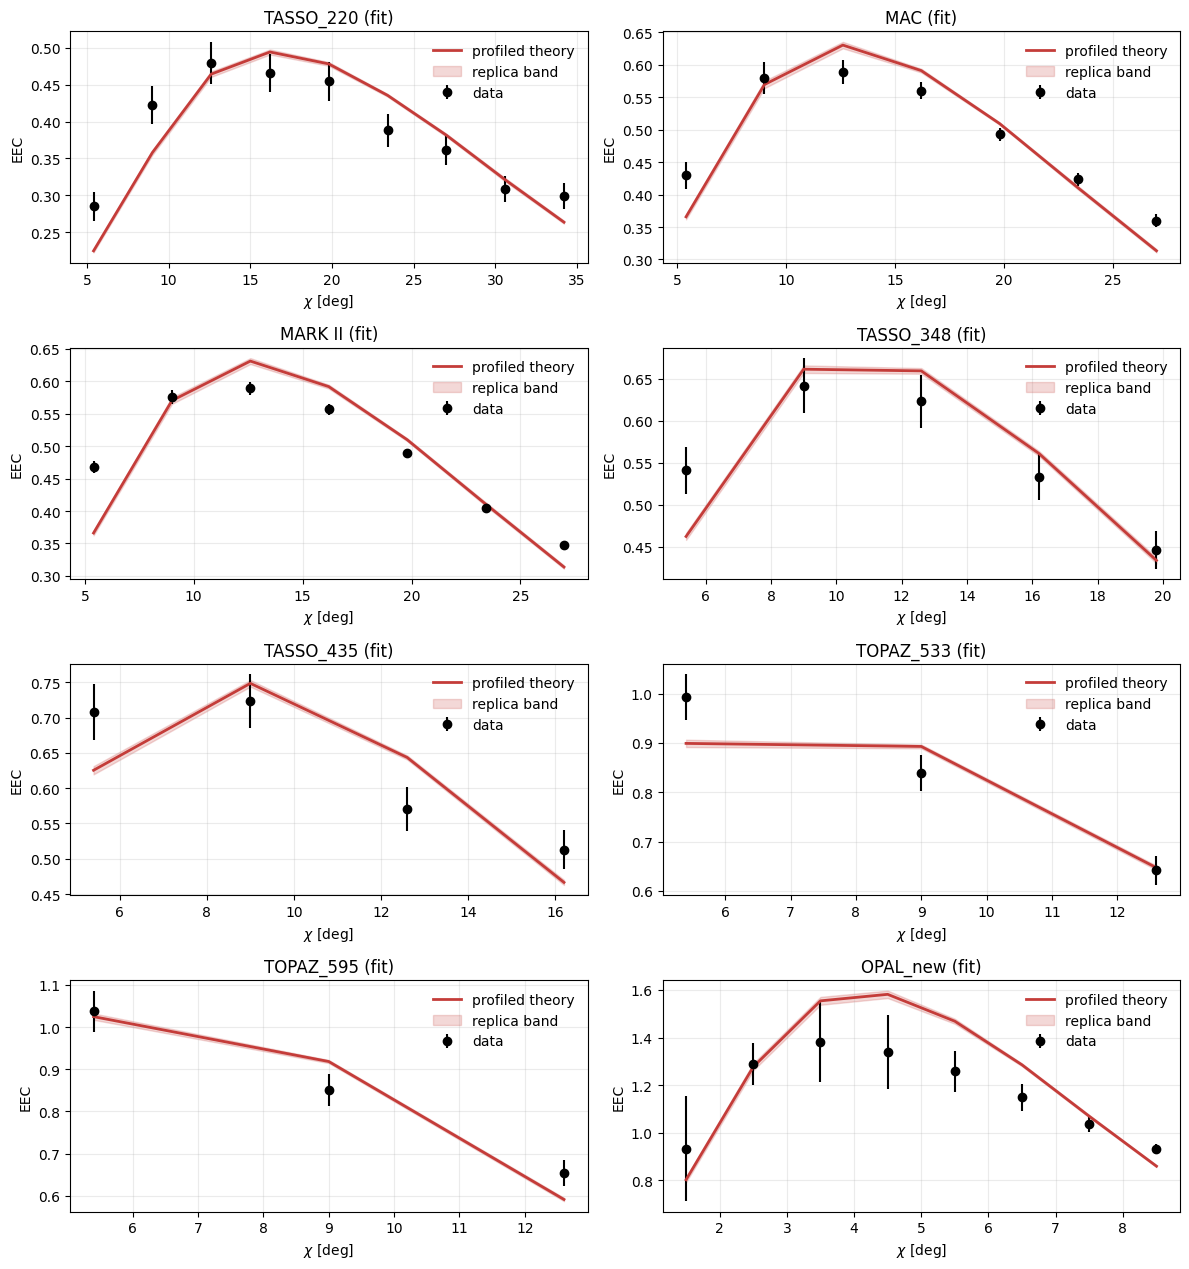

In [10]:
plot_df = replica_comparison_df.copy() if "replica_comparison_df" in globals() else comparison_df.copy()
dataset_order = list(summary_df["dataset"])
ncols = 2
nrows = int(np.ceil(len(dataset_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows), sharex=False)
axes = np.atleast_1d(axes).ravel()

for ax, dataset_name in zip(axes, dataset_order):
    df = plot_df.loc[plot_df["dataset"] == dataset_name].sort_values("chi_deg")
    used_in_fit = bool(df["used_in_shape_fit"].iloc[0])
    label = f"{dataset_name} (fit)" if used_in_fit else f"{dataset_name} (excluded)"

    ax.errorbar(df["chi_deg"], df["data"], yerr=df["error"], fmt="o", color="black", label="data")
    ax.plot(df["chi_deg"], df["theory_profiled"], color="#c43c39", lw=2.0, label="profiled theory")
    if "theory_profiled_std" in df.columns:
        theory_profiled_std = np.asarray(df["theory_profiled_std"], dtype=float)
        ax.fill_between(
            df["chi_deg"],
            df["theory_profiled"] - theory_profiled_std,
            df["theory_profiled"] + theory_profiled_std,
            color="#c43c39",
            alpha=0.2,
            label="replica band",
        )
    ax.set_title(label)
    ax.set_xlabel(r"$\chi$ [deg]")
    ax.set_ylabel("EEC")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

for ax in axes[len(dataset_order):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
